# 01 — Exploratory Data Analysis
**What this notebook does:**
- Loads your 3 clean data files
- Makes charts showing who dominated each era
- Measures title concentration by decade

Run each cell one at a time with **Shift + Enter**

In [2]:
# CELL 1 — Import tools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (12, 5)

print('Ready!')

Ready!


In [3]:
# CELL 2 — Load your 3 files
matches = pd.read_csv('../data/processed/atp_matches_clean.csv')
slams   = pd.read_csv('../data/processed/slams_clean.csv')
players = pd.read_csv('../data/processed/players_clean.csv')

print('Matches rows:',  len(matches))
print('Slams rows:',    len(slams))
print('Players rows:',  len(players))

Matches rows: 74906
Slams rows: 292
Players rows: 65989


C:\Users\ashle\AppData\Local\Temp\ipykernel_26952\599400487.py:4: DtypeWarning: Columns (0: wikidata_id) have mixed types. Specify dtype option on import or set low_memory=False.
  players = pd.read_csv('../data/processed/players_clean.csv')


In [4]:
# CELL 3 — Preview each file so you know what you're working with
print('--- MATCHES ---')
print(matches.columns.tolist())
print()
print('--- SLAMS ---')
print(slams.columns.tolist())
print()
print('--- PLAYERS ---')
print(players.columns.tolist())

--- MATCHES ---
['tourney_id', 'tourney_name', 'surface', 'draw_size', 'tourney_level', 'tourney_date', 'match_num', 'winner_id', 'winner_seed', 'winner_entry', 'winner_name', 'winner_hand', 'winner_ht', 'winner_ioc', 'winner_age', 'loser_id', 'loser_seed', 'loser_entry', 'loser_name', 'loser_hand', 'loser_ht', 'loser_ioc', 'loser_age', 'score', 'best_of', 'round', 'minutes', 'w_ace', 'w_df', 'w_svpt', 'w_1stIn', 'w_1stWon', 'w_2ndWon', 'w_SvGms', 'w_bpSaved', 'w_bpFaced', 'l_ace', 'l_df', 'l_svpt', 'l_1stIn', 'l_1stWon', 'l_2ndWon', 'l_SvGms', 'l_bpSaved', 'l_bpFaced', 'winner_rank', 'winner_rank_points', 'loser_rank', 'loser_rank_points']

--- SLAMS ---
['YEAR', 'TOURNAMENT', 'WINNER', 'RUNNER-UP', 'WINNER_NATIONALITY', 'WINNER_ATP_RANKING', 'RUNNER-UP_ATP_RANKING', 'WINNER_LEFT_OR_RIGHT_HANDED', 'TOURNAMENT_SURFACE', 'WINNER_PRIZE']

--- PLAYERS ---
['player_id', 'name_first', 'name_last', 'hand', 'dob', 'ioc', 'height', 'wikidata_id', 'player_name']


In [5]:
# CELL 4 — Fix the date column in matches
# Right now tourney_date is a number like 20000110
# This converts it to a proper date: 2000-01-10
matches['tourney_date'] = pd.to_datetime(matches['tourney_date'].astype(str), format='%Y%m%d', errors='coerce')
matches['year'] = matches['tourney_date'].dt.year

print('Date range:', matches['tourney_date'].min(), 'to', matches['tourney_date'].max())
matches[['tourney_name', 'tourney_date', 'winner_name', 'loser_name']].head()

Date range: 2000-01-03 00:00:00 to 2024-12-18 00:00:00


,tourney_name,tourney_date,winner_name,loser_name
0,Auckland,2000-01-10,Tommy Haas,Jeff Tarango
1,Auckland,2000-01-10,Juan Balcells,Franco Squillari
2,Auckland,2000-01-10,Alberto Martin,Alberto Berasategui
3,Auckland,2000-01-10,Juan Carlos Ferrero,Roger Federer
4,Auckland,2000-01-10,Michael Sell,Nicolas Escude


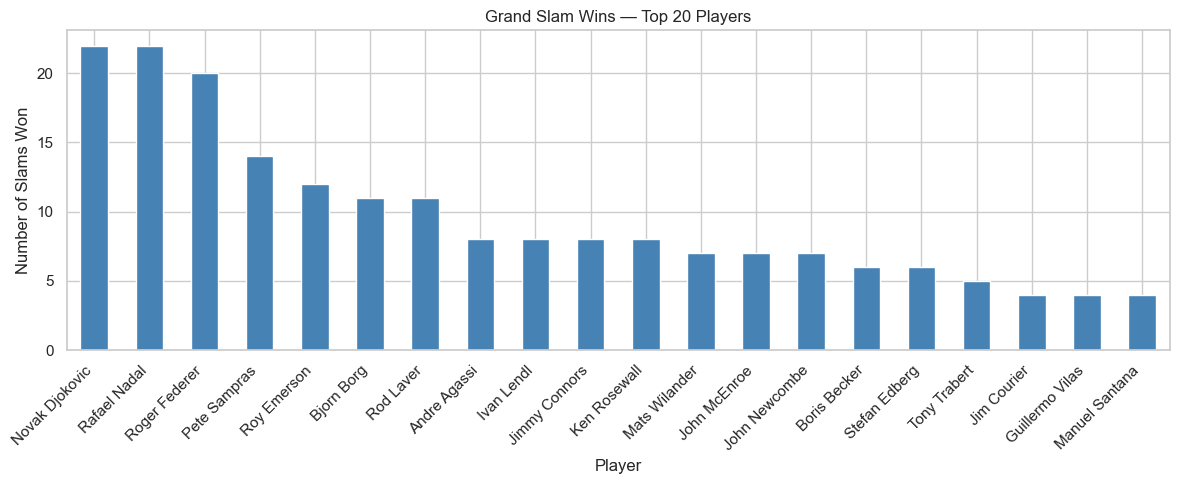

WINNER
Novak Djokovic     22
Rafael Nadal       22
Roger Federer      20
Pete Sampras       14
Roy Emerson        12
Bjorn Borg         11
Rod Laver          11
Andre Agassi        8
Ivan Lendl          8
Jimmy Connors       8
Ken Rosewall        8
Mats Wilander       7
John McEnroe        7
John Newcombe       7
Boris Becker        6
Stefan Edberg       6
Tony Trabert        5
Jim Courier         4
Guillermo Vilas     4
Manuel Santana      4
Name: count, dtype: int64


In [6]:
# CELL 5 — Top 20 Grand Slam winners of all time
top_winners = slams['WINNER'].value_counts().head(20)

fig, ax = plt.subplots()
top_winners.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Grand Slam Wins — Top 20 Players')
ax.set_xlabel('Player')
ax.set_ylabel('Number of Slams Won')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(top_winners)

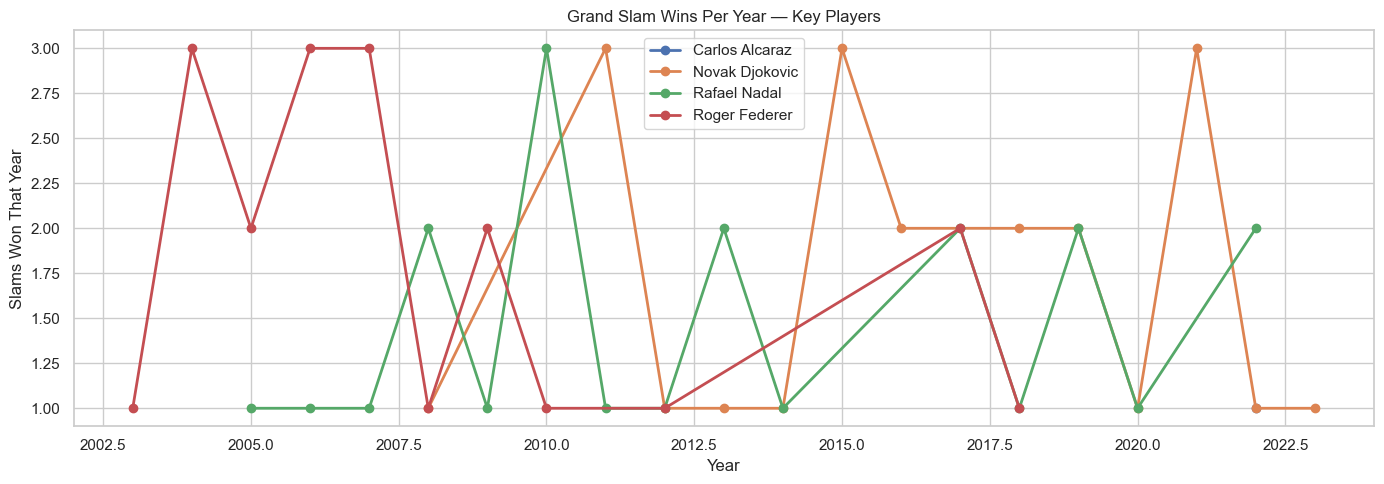

In [7]:
# CELL 6 — Slams won per year (who won what each year)
slams_by_year = slams.groupby(['YEAR', 'WINNER']).size().reset_index(name='wins')

# Focus on the Big Three + new guard
players_of_interest = ['Novak Djokovic', 'Rafael Nadal', 'Roger Federer', 
                        'Carlos Alcaraz', 'Jannik Sinner']

filtered = slams_by_year[slams_by_year['WINNER'].isin(players_of_interest)]

fig, ax = plt.subplots(figsize=(14, 5))
for player, group in filtered.groupby('WINNER'):
    ax.plot(group['YEAR'], group['wins'], marker='o', label=player, linewidth=2)

ax.set_title('Grand Slam Wins Per Year — Key Players')
ax.set_xlabel('Year')
ax.set_ylabel('Slams Won That Year')
ax.legend()
plt.tight_layout()
plt.show()

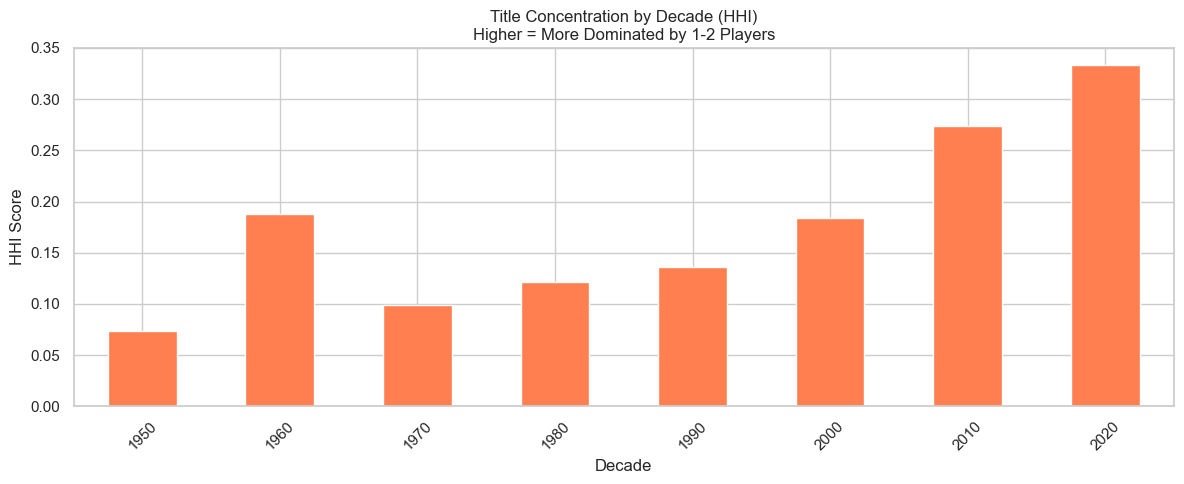

decade
1950    0.073750
1960    0.187500
1970    0.099346
1980    0.121631
1990    0.136250
2000    0.183750
2010    0.273750
2020    0.333333
Name: WINNER, dtype: float64


In [8]:
# CELL 7 — How concentrated were titles each decade?
# HHI = Herfindahl-Hirschman Index
# 0 = everyone wins equally, 1 = one player wins everything
slams['decade'] = (slams['YEAR'] // 10) * 10

def hhi(series):
    shares = series.value_counts(normalize=True)
    return (shares ** 2).sum()

hhi_by_decade = slams.groupby('decade')['WINNER'].apply(hhi)

fig, ax = plt.subplots()
hhi_by_decade.plot(kind='bar', ax=ax, color='coral')
ax.set_title('Title Concentration by Decade (HHI)\nHigher = More Dominated by 1-2 Players')
ax.set_xlabel('Decade')
ax.set_ylabel('HHI Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(hhi_by_decade)

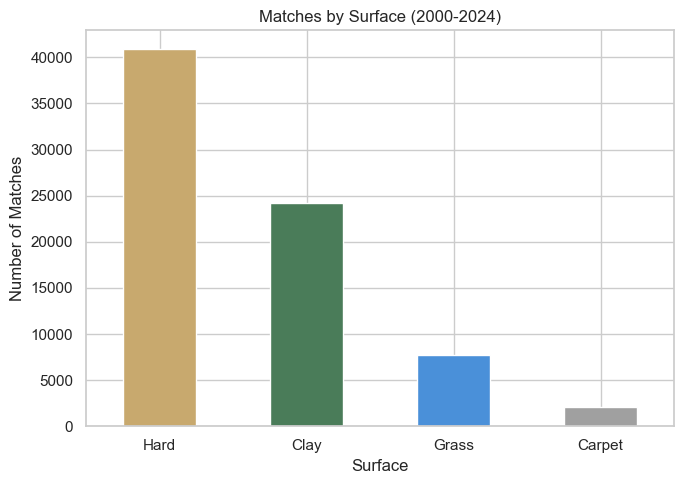

In [9]:
# CELL 8 — Surface breakdown in match data
surface_counts = matches['surface'].value_counts()

fig, ax = plt.subplots(figsize=(7, 5))
surface_counts.plot(kind='bar', ax=ax, color=['#c8a96e', '#4a7c59', '#4a90d9', '#a0a0a0'])
ax.set_title('Matches by Surface (2000-2024)')
ax.set_xlabel('Surface')
ax.set_ylabel('Number of Matches')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

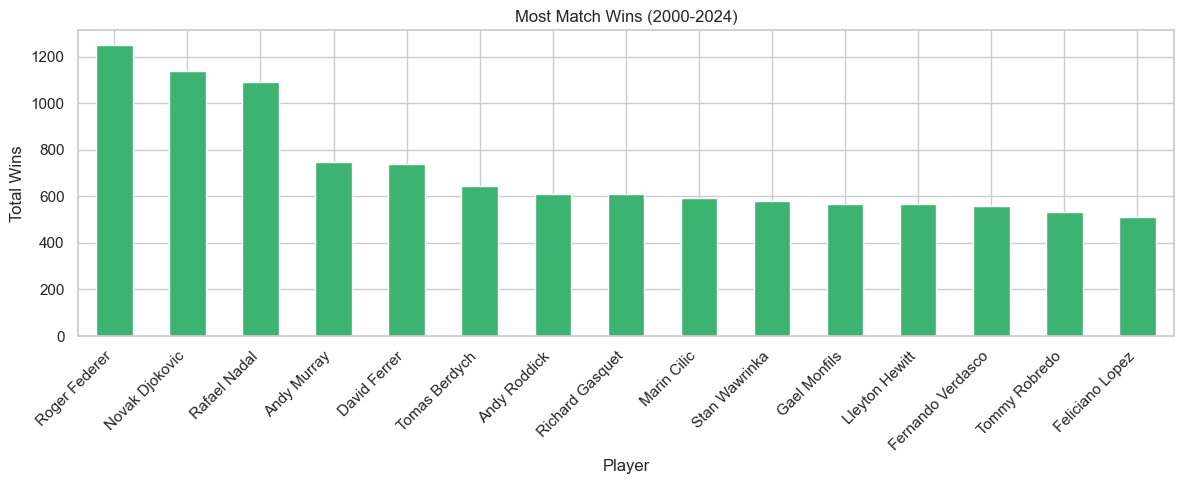

winner_name
Roger Federer        1250
Novak Djokovic       1139
Rafael Nadal         1091
Andy Murray           748
David Ferrer          740
Tomas Berdych         643
Andy Roddick          612
Richard Gasquet       609
Marin Cilic           592
Stan Wawrinka         581
Gael Monfils          567
Lleyton Hewitt        565
Fernando Verdasco     559
Tommy Robredo         532
Feliciano Lopez       512
Name: count, dtype: int64


In [10]:
# CELL 9 — Who won the most matches overall (2000-2024)?
top_match_winners = matches['winner_name'].value_counts().head(15)

fig, ax = plt.subplots()
top_match_winners.plot(kind='bar', ax=ax, color='mediumseagreen')
ax.set_title('Most Match Wins (2000-2024)')
ax.set_xlabel('Player')
ax.set_ylabel('Total Wins')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(top_match_winners)

In [11]:
# CELL 10 — Only Grand Slam matches from the match data
# tourney_level = 'G' means Grand Slam
grand_slams_only = matches[matches['tourney_level'] == 'G']

slam_winners = grand_slams_only[grand_slams_only['round'] == 'F']['winner_name'].value_counts().head(10)

print('Grand Slam final winners (from match data):')
print(slam_winners)

Grand Slam final winners (from match data):
winner_name
Novak Djokovic     24
Rafael Nadal       22
Roger Federer      20
Carlos Alcaraz      4
Andre Agassi        3
Andy Murray         3
Stan Wawrinka       3
Gustavo Kuerten     2
Pete Sampras        2
Marat Safin         2
Name: count, dtype: int64
